# 02 — Обучение Uzbek NER

Ноутбук реализует полный воспроизводимый цикл для конкурсной задачи:

1. проверка схемы, контрольных сумм и символьных границ;
2. преобразование exact character spans в BIO-разметку;
3. токенизация **исходного текста без изменяющей длину нормализации**;
4. sliding windows для длинных документов;
5. fine-tuning multilingual Transformer;
6. выбор checkpoint по **exact-span micro-F1**, а не по token accuracy или loss;
7. Precision / Recall / F1 по ORG, NAME, GEO, micro и macro;
8. сохранение модели, предсказаний, метрик и примеров ошибок.

Модель и параметры окон по умолчанию берутся из \`baseline/common.py\`. Для быстрого smoke-test измените поле \`fast_run\` в \`Config\` на \`True\`.

> Важное правило: апострофы, Unicode, регистр и пробелы в исходной строке не меняются. Иначе координаты \`start/end\` перестанут соответствовать конкурсному gold.


## 0. Окружение

Зависимости проекта уже перечислены в \`ner_uz_hackathon_participant/requirements.txt\`. При необходимости выполните следующую ячейку один раз, затем перезапустите kernel. CUDA-сборку PyTorch устанавливайте только в совместимом Linux/CUDA-окружении.


In [1]:
# Раскомментируйте подходящую команду при необходимости.
%pip install -r /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/requirements.txt
# Универсальный вариант для notebook-окружения без CUDA-specific index:
%pip install "torch>=2.3" "transformers>=4.45" "tokenizers>=0.20" "tqdm>=4.66"


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 132.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 187.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 180.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 82.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 106.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 159.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 128.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 116.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Конфигурация и воспроизводимость

Пути определяются автоматически: ноутбук можно запускать из корня репозитория или из каталога участника.


In [20]:
from pathlib import Path
import sys

INPUT_ROOT = Path("/kaggle/input")

# Автоматически находим папку, внутри которой лежит baseline/.
common_candidates = list(INPUT_ROOT.rglob("baseline/common.py"))

print("Найденные common.py:")
for path in common_candidates:
    print(" ", path)

if not common_candidates:
    raise FileNotFoundError(
        "В /kaggle/input не найден baseline/common.py"
    )

COMMON_PATH = common_candidates[0]
PROJECT_DIR = COMMON_PATH.parent.parent

# Находим директорию с train.jsonl и dev.jsonl.
data_candidates = [
    path.parent
    for path in INPUT_ROOT.rglob("train.jsonl")
    if (path.parent / "dev.jsonl").exists()
]

print("\nНайденные директории данных:")
for path in data_candidates:
    print(" ", path)

if not data_candidates:
    raise FileNotFoundError(
        "Не найдена директория с train.jsonl и dev.jsonl"
    )

DATA_DIR = data_candidates[0]

TRAIN_PATH = Path('/kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data') / "train.jsonl"
DEV_PATH = Path('/kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data') / "dev.jsonl"
AUGMENTATION_PATH = [DATA_DIR / "hard_negatives.jsonl", DATA_DIR / "morphology.jsonl", DATA_DIR / "case.jsonl"]

manifest_candidates = list(INPUT_ROOT.rglob("dataset_manifest.json"))
MANIFEST_PATH = manifest_candidates[0] if manifest_candidates else None

# Результаты обязательно сохраняем в /kaggle/working:
ARTIFACT_DIR = Path("/kaggle/working/artifacts/baseline_notebook")
MODEL_DIR = ARTIFACT_DIR / "model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Для `from baseline.common import ...` нужен родитель папки baseline.
sys.path.insert(0, str(PROJECT_DIR))

print("\nPROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_PATH:", TRAIN_PATH)
print("DEV_PATH:", DEV_PATH)
print("MANIFEST_PATH:", MANIFEST_PATH)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

Найденные common.py:
  /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/baseline/common.py

Найденные директории данных:
  /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data2
  /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data

PROJECT_DIR: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant
DATA_DIR: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data2
TRAIN_PATH: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data/train.jsonl
DEV_PATH: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data/dev.jsonl
MANIFEST_PATH: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant/data/dataset_manifest.json
ARTIFACT_DIR: /kaggle/working/artifacts/baseline_notebook


In [21]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
import sys
import time
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, List

import torch
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup,
)
# Единая реализация подготовки, обучения и инференса из папки baseline.
from baseline.common import (
    TokenizedNerDataset as BaselineTokenizedNerDataset,
    load_fast_tokenizer as baseline_load_fast_tokenizer,
    validate_window as baseline_validate_window,
)
from baseline.predict import (
    _build_windows as baseline_build_windows,
    _decode_records as baseline_decode_records,
    _predict_token_scores as baseline_predict_token_scores,
)

MODEL = "FacebookAI/xlm-roberta-base"
MAX_LENGTH = 512
STRIDE = 128

@dataclass(frozen=True)
class Config:
    model_name: str = MODEL
    max_length: int = MAX_LENGTH
    stride: int = STRIDE
    epochs: int = 20
    train_batch_size: int = 8
    eval_batch_size: int = 16
    gradient_accumulation_steps: int = 2
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.10
    max_grad_norm: float = 1.0
    seed: int = 42
    num_workers: int = 0
    use_amp: bool = True
    fast_run: bool = False
    fast_train_records: int = 256
    fast_dev_records: int = 128

CFG = Config()

def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resolve_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

set_seed(CFG.seed)
DEVICE = resolve_device()
USE_AMP = CFG.use_amp and DEVICE.type == "cuda"

print("Project:", PROJECT_DIR)
print("Artifacts:", ARTIFACT_DIR)
print("Device:", DEVICE, "| AMP:", USE_AMP)
print(json.dumps(asdict(CFG), ensure_ascii=False, indent=2))


Project: /kaggle/input/datasets/daryakoryakovskaya/ner-file/ner_uz_hackathon_participant
Artifacts: /kaggle/working/artifacts/baseline_notebook
Device: cuda | AMP: True
{
  "model_name": "FacebookAI/xlm-roberta-base",
  "max_length": 512,
  "stride": 128,
  "epochs": 20,
  "train_batch_size": 8,
  "eval_batch_size": 16,
  "gradient_accumulation_steps": 2,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "max_grad_norm": 1.0,
  "seed": 42,
  "num_workers": 0,
  "use_amp": true,
  "fast_run": false,
  "fast_train_records": 256,
  "fast_dev_records": 128
}


## 2. Загрузка и строгая валидация данных

Проверяются уникальность \`hash\`, допустимые классы, диапазоны координат, дубли и пересечения. Дополнительно сверяются SHA-256 train/dev с manifest.


In [22]:
ENTITY_LABELS = ("ORG", "NAME", "GEO")
TAGS = ("O", "B-ORG", "I-ORG", "B-NAME", "I-NAME", "B-GEO", "I-GEO")
TAG_TO_ID = {tag: i for i, tag in enumerate(TAGS)}
ID_TO_TAG = {i: tag for tag, i in TAG_TO_ID.items()}

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def validate_record(raw: Any, source: str) -> dict[str, Any]:
    if not isinstance(raw, dict):
        raise ValueError(f"{source}: record must be an object")
    record_hash, text, entities = raw.get("hash"), raw.get("text"), raw.get("entities")
    if not isinstance(record_hash, str) or not record_hash:
        raise ValueError(f"{source}: invalid hash")
    if not isinstance(text, str):
        raise ValueError(f"{source}: text must be a string")
    if not isinstance(entities, list):
        raise ValueError(f"{source}: entities must be a list")

    clean, seen = [], set()
    for j, entity in enumerate(entities):
        if not isinstance(entity, dict):
            raise ValueError(f"{source}/entities[{j}]: must be an object")
        label, start, end = entity.get("label"), entity.get("start"), entity.get("end")
        if label not in ENTITY_LABELS:
            raise ValueError(f"{source}/entities[{j}]: invalid label {label!r}")
        if (
            not isinstance(start, int) or isinstance(start, bool)
            or not isinstance(end, int) or isinstance(end, bool)
            or not 0 <= start < end <= len(text)
        ):
            raise ValueError(f"{source}/entities[{j}]: invalid offsets")
        key = (label, start, end)
        if key in seen:
            raise ValueError(f"{source}/entities[{j}]: duplicate entity")
        seen.add(key)
        clean.append({"label": label, "start": start, "end": end})

    clean.sort(key=lambda e: (e["start"], e["end"], e["label"]))
    for left, right in zip(clean, clean[1:]):
        if right["start"] < left["end"]:
            raise ValueError(f"{source}: overlapping entities are unsupported")
    return {"hash": record_hash, "text": text, "entities": clean}

def read_jsonl(path: Path, limit: int | None = None, augmentations_path: List[str] | None = None) -> list[dict[str, Any]]:
    records, hashes = [], set()
    with path.open(encoding="utf-8") as stream:
        for line_no, line in enumerate(stream, 1):
            if not line.strip():
                raise ValueError(f"{path}:{line_no}: empty line")
            record = validate_record(json.loads(line), f"{path}:{line_no}")
            if record["hash"] in hashes:
                raise ValueError(f"{path}:{line_no}: duplicate hash")
            hashes.add(record["hash"])
            records.append(record)
            if limit is not None and len(records) >= limit:
                break
    if augmentations_path is not None:
        for aug_path in augmentations_path:
            with aug_path.open(encoding="utf-8") as stream:
                for line_no, line in enumerate(stream, 1):
                    if not line.strip():
                        raise ValueError(f"{path}:{line_no}: empty line")
                    record = validate_record(json.loads(line), f"{path}:{line_no}")
                    if record["hash"] in hashes:
                        raise ValueError(f"{path}:{line_no}: duplicate hash")
                    hashes.add(record["hash"])
                    records.append(record)
                    if limit is not None and len(records) >= limit:
                        break
    if not records:
        raise ValueError(f"{path}: no records")
    return records

"""manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
for split, path in (("train", TRAIN_PATH), ("dev", DEV_PATH)):
    expected = manifest["splits"][split]["sha256"]
    actual = sha256(path)
    if actual != expected:
        raise ValueError(f"SHA-256 mismatch for {path}: {actual} != {expected}")
print("SHA-256 train/dev совпадают с manifest.")"""

train_limit = CFG.fast_train_records if CFG.fast_run else None
dev_limit = CFG.fast_dev_records if CFG.fast_run else None
train_records = read_jsonl(TRAIN_PATH, train_limit, augmentations_path = AUGMENTATION_PATH)
dev_records = read_jsonl(DEV_PATH, dev_limit)
print(f"Train: {len(train_records):,}; dev: {len(dev_records):,}")


Train: 45,206; dev: 1,500


In [23]:
"""Normalize internal apostrophe variants without changing string length.

External quote marks are preserved. English contractions and possessives are
preserved by default so that multilingual examples are not Uzbek-normalized.
"""

from __future__ import annotations

import argparse
from collections import Counter
from pathlib import Path
from typing import Any

CANONICAL = "ʻ"  # U+02BB MODIFIER LETTER TURNED COMMA; dominant in this dataset.
VARIANTS = {"'", "’", "‘", "ʼ", "`", "´", "ʹ", "ʾ", "ʿ", "＇"}
ENGLISH_ENDINGS = {"s", "t", "re", "ve", "ll", "d", "m"}


def word_bounds(text: str, index: int) -> tuple[int, int]:
    left = index
    while left > 0 and (text[left - 1].isalnum() or text[left - 1] in VARIANTS):
        left -= 1
    right = index + 1
    while right < len(text) and (text[right].isalnum() or text[right] in VARIANTS):
        right += 1
    return left, right


def looks_english(text: str, index: int) -> bool:
    left, right = word_bounds(text, index)
    before, after = text[left:index], text[index + 1 : right]
    if after.casefold() in ENGLISH_ENDINGS and before.isascii() and after.isascii():
        return True
    # O'Connor, D'Angelo and similar names are not Uzbek o'/g' spellings.
    if before.casefold() in {"o", "d"} and after[:1].isupper() and after.isascii():
        return True
    return False


def normalize_text(text: str, *, preserve_english: bool) -> tuple[str, Counter[str]]:
    chars = list(text)
    changes: Counter[str] = Counter()
    for index, char in enumerate(chars):
        if char not in VARIANTS or char == CANONICAL:
            continue
        if index == 0 or index + 1 == len(chars):
            continue
        if not (chars[index - 1].isalnum() and chars[index + 1].isalnum()):
            continue  # external quote, not an internal apostrophe
        if preserve_english and looks_english(text, index):
            continue
        chars[index] = CANONICAL
        changes[char] += 1
    return "".join(chars), changes


def normalize_record(record: dict[str, Any], *, preserve_english: bool) -> tuple[dict[str, Any], Counter[str], int]:
    normalized, changes = normalize_text(record["text"], preserve_english=preserve_english)
    if len(normalized) != len(record["text"]):
        raise AssertionError("apostrophe normalization must preserve text length")
    entity_changes = sum(
        record["text"][entity["start"] : entity["end"]]
        != normalized[entity["start"] : entity["end"]]
        for entity in record["entities"]
    )
    result = {"hash": record["hash"], "text": normalized, "entities": record["entities"]}
    validate_record(result, record["hash"])
    return result, changes, entity_changes



def preprocess(records):
    records_preprocessed = []
    normalize_english = True
    changes: Counter[str] = Counter()
    changed_documents = 0
    changed_entities = 0
    for record in records:
        normalized, record_changes, record_entity_changes = normalize_record(
            record,
            preserve_english=not normalize_english,
        )
        records_preprocessed.append(normalized)
        changes.update(record_changes)
        changed_documents += normalized["text"] != record["text"]
        changed_entities += record_entity_changes
    return records_preprocessed

In [24]:
def split_stats(records: list[dict[str, Any]]) -> dict[str, Any]:
    labels = Counter(e["label"] for r in records for e in r["entities"])
    lengths = sorted(len(r["text"]) for r in records)
    return {
        "documents": len(records),
        "empty_documents": sum(not r["entities"] for r in records),
        "entities": sum(labels.values()),
        **{label: labels[label] for label in ENTITY_LABELS},
        "median_chars": lengths[len(lengths) // 2],
        "max_chars": lengths[-1],
    }

print("TRAIN", json.dumps(split_stats(train_records), ensure_ascii=False, indent=2))
print("DEV  ", json.dumps(split_stats(dev_records), ensure_ascii=False, indent=2))
print("\nПример exact spans:")
example = next(r for r in train_records if r["entities"])
print(example["text"][:350])
for entity in example["entities"][:8]:
    print(entity, "=>", repr(example["text"][entity["start"]:entity["end"]]))


TRAIN {
  "documents": 45206,
  "empty_documents": 2486,
  "entities": 207449,
  "ORG": 75214,
  "NAME": 66536,
  "GEO": 65699,
  "median_chars": 86,
  "max_chars": 22668
}
DEV   {
  "documents": 1500,
  "empty_documents": 275,
  "entities": 7698,
  "ORG": 2659,
  "NAME": 2319,
  "GEO": 2720,
  "median_chars": 171,
  "max_chars": 18975
}

Пример exact spans:
Тошкент вилоятининг Бўка-Бекобод йўлида ИИБ ходими томонидан уриб юборилиб, Дўстлик каналига ташлангани айтилган 43 ёшли фуқаронинг жасади 80 кун ўтиб топилди. Марҳумнинг яқинлари маълум қилишича, жасад 28-февраль куни соат 10:30 ларда Дўстлик каналидан, сув оқимининг қуйи қисмидан аниқланган. У қум остида қолиб кетган бўлган. Қариндошларининг айти
{'label': 'GEO', 'start': 0, 'end': 19} => 'Тошкент вилоятининг'
{'label': 'GEO', 'start': 20, 'end': 39} => 'Бўка-Бекобод йўлида'
{'label': 'ORG', 'start': 40, 'end': 43} => 'ИИБ'
{'label': 'GEO', 'start': 76, 'end': 92} => 'Дўстлик каналига'
{'label': 'GEO', 'start': 236, 'end': 253} =

## 3. Предобработка: tokenizer offsets → BIO

Почему именно так:

- тексты длиной до десятков тысяч символов превращаются в перекрывающиеся окна;
- fast tokenizer возвращает координаты каждого subword в исходной Python-строке;
- special tokens получают \`-100\` и не участвуют в loss;
- если сущность обрезана границей окна, её токены в этом окне маскируются. Полная копия сущности остаётся в соседнем окне;
- Unicode/NFKC, апострофы, регистр и пробелы не нормализуются: это сохраняет exact offsets.

Если граница gold попала внутрь одного tokenizer token, token classification не может восстановить её идеально. Следующая проверка показывает число таких случаев.


In [25]:
tokenizer = baseline_load_fast_tokenizer(CFG.model_name)
baseline_validate_window(tokenizer, CFG.max_length, CFG.stride)
from typing import Any

from tqdm.auto import tqdm

from baseline.common import tokenize_windows


def _token_to_dict(
    tokenizer,
    text: str,
    token_id: int,
    start: int,
    end: int,
) -> dict[str, Any]:
    return {
        "token": tokenizer.convert_ids_to_tokens(int(token_id)),
        "token_id": int(token_id),
        "text": text[start:end],
        "start": start,
        "end": end,
        "length": end - start,
    }


def render_all_token_boundaries(
    text,
    all_tokens,
    *,
    gold_start,
    gold_end,
    context_size=50,
):
    context_start = max(0, gold_start - context_size)
    context_end = min(len(text), gold_end + context_size)

    context_tokens = sorted(
        [
            token
            for token in all_tokens
            if (
                token["start"] < context_end
                and token["end"] > context_start
            )
        ],
        key=lambda token: (
            token["start"],
            token["end"],
        ),
    )

    result = []
    cursor = context_start

    for token in context_tokens:
        token_start = max(token["start"], context_start)
        token_end = min(token["end"], context_end)

        if token_end <= cursor:
            continue

        if token_start > cursor:
            # Обычно здесь находятся пробелы.
            result.append(text[cursor:token_start])

        result.append(
            "⟪" + text[token_start:token_end] + "⟫"
        )
        cursor = token_end

    if cursor < context_end:
        result.append(text[cursor:context_end])

    return "".join(result).replace("\n", "\\n")


def boundary_alignment_issues(
    records: list[dict[str, Any]],
    tokenizer,
    *,
    max_length: int,
    stride: int,
    context_size: int = 50,
) -> list[dict[str, Any]]:
    """
    Показывает токены, которые пересекают границы gold-сущностей.

    Проблемный большой токен:
      token.start < gold boundary < token.end

    То есть gold-граница находится внутри tokenizer-токена.
    """

    issues: list[dict[str, Any]] = []

    for record in tqdm(
        records,
        desc="Check boundary alignment",
        unit="doc",
    ):
        text = record["text"]

        # Собираем токены из всех sliding windows.
        # Одинаковые offsets из overlap-окон удаляем.
        tokens_by_offset: dict[
            tuple[int, int],
            dict[str, Any],
        ] = {}

        windows = tokenize_windows(
            tokenizer,
            text,
            max_length=max_length,
            stride=stride,
        )

        for feature, offsets in windows:
            input_ids = feature["input_ids"]

            for token_id, (start, end) in zip(
                input_ids,
                offsets,
                strict=True,
            ):
                # Special tokens обычно имеют offsets (0, 0).
                if start == end:
                    continue

                offset = (start, end)

                if offset not in tokens_by_offset:
                    tokens_by_offset[offset] = _token_to_dict(
                        tokenizer,
                        text,
                        token_id,
                        start,
                        end,
                    )

        tokens = sorted(
            tokens_by_offset.values(),
            key=lambda token: (
                token["start"],
                token["end"],
            ),
        )

        token_starts = {token["start"] for token in tokens}
        token_ends = {token["end"] for token in tokens}

        for entity in record["entities"]:
            gold_start = entity["start"]
            gold_end = entity["end"]

            start_aligned = gold_start in token_starts
            end_aligned = gold_end in token_ends

            if start_aligned and end_aligned:
                continue

            # Токены, внутри которых находится gold start.
            tokens_crossing_start = [
                token
                for token in tokens
                if token["start"] < gold_start < token["end"]
            ]

            # Токены, внутри которых находится gold end.
            tokens_crossing_end = [
                token
                for token in tokens
                if token["start"] < gold_end < token["end"]
            ]

            # Все токены, пересекающие gold-сущность.
            overlapping_tokens = [
                token
                for token in tokens
                if (
                    token["start"] < gold_end
                    and token["end"] > gold_start
                )
            ]

            # Уникальные проблемные большие токены.
            problem_tokens_by_offset = {
                (token["start"], token["end"]): token
                for token in (
                    tokens_crossing_start
                    + tokens_crossing_end
                )
            }

            problem_tokens = sorted(
                problem_tokens_by_offset.values(),
                key=lambda token: (
                    token["start"],
                    token["end"],
                ),
            )

            token_aligned_start = (
                min(token["start"] for token in overlapping_tokens)
                if overlapping_tokens
                else None
            )
            token_aligned_end = (
                max(token["end"] for token in overlapping_tokens)
                if overlapping_tokens
                else None
            )

            token_aligned_text = (
                text[token_aligned_start:token_aligned_end]
                if (
                    token_aligned_start is not None
                    and token_aligned_end is not None
                )
                else None
            )

            detailed_problem_tokens = []

            for token in problem_tokens:
                crosses_start = (
                    token["start"]
                    < gold_start
                    < token["end"]
                )
                crosses_end = (
                    token["start"]
                    < gold_end
                    < token["end"]
                )

                detailed_problem_tokens.append({
                    **token,
                    "crosses_gold_start": crosses_start,
                    "crosses_gold_end": crosses_end,

                    # Лишняя часть токена слева от gold.
                    "extra_before_gold": (
                        text[token["start"]:gold_start]
                        if crosses_start
                        else ""
                    ),

                    # Лишняя часть токена справа от gold.
                    "extra_after_gold": (
                        text[gold_end:token["end"]]
                        if crosses_end
                        else ""
                    ),
                })

            issues.append({
                "hash": record["hash"],
                "label": entity["label"],

                "gold_text": text[gold_start:gold_end],
                "gold_start": gold_start,
                "gold_end": gold_end,
                "gold_offsets": (gold_start, gold_end),

                "start_aligned": start_aligned,
                "end_aligned": end_aligned,

                # Именно токены, разрезающие gold-границы.
                "problem_tokens": detailed_problem_tokens,

                # Все токены, из которых tokenizer пытается
                # составить gold-сущность.
                "overlapping_tokens": overlapping_tokens,

                # Минимальный span из целых токенов.
                "token_aligned_text": token_aligned_text,
                "token_aligned_offsets": (
                    token_aligned_start,
                    token_aligned_end,
                ),

                # ⟪...⟫ обозначает проблемные tokenizer-токены.
                "tokenizer_context": render_all_token_boundaries(
                    text,
                    tokens,
                    gold_start=gold_start,
                    gold_end=gold_end,
                    context_size=context_size,
                ),
            })

    return issues

alignment_issues = boundary_alignment_issues(
    train_records + dev_records,
    tokenizer,
    max_length=CFG.max_length,
    stride=CFG.stride,
)

print(f"Найдено проблем: {len(alignment_issues):,}")


Check boundary alignment:   0%|          | 0/46706 [00:00<?, ?doc/s]

Найдено проблем: 48


In [26]:
# Используем готовый Dataset из baseline.common, а не локальную копию.
train_dataset = BaselineTokenizedNerDataset(
    train_records,
    tokenizer,
    max_length=CFG.max_length,
    stride=CFG.stride,
    description="Tokenize train via baseline",
)
collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding=True)

generator = torch.Generator().manual_seed(CFG.seed)
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.train_batch_size,
    shuffle=True,
    collate_fn=collator,
    num_workers=CFG.num_workers,
    generator=generator,
    pin_memory=DEVICE.type == "cuda",
)
print(f"Train windows: {len(train_dataset):,}")
print("BIO alignment and sliding windows: baseline.common.TokenizedNerDataset")


Tokenize train via baseline:   0%|          | 0/45206 [00:00<?, ?doc/s]

Train windows: 50,766
BIO alignment and sliding windows: baseline.common.TokenizedNerDataset


## 4. Exact-span inference и метрики

Логиты одинаковых токенов из перекрывающихся окон усредняются. После BIO-decoding получаются исходные \`start/end\`. Итоговая метрика совпадает с условием: TP требует одновременного совпадения \`hash + label + start + end\`.


In [28]:
# Готовая сборка окон из baseline.predict.
dev_windows = baseline_build_windows(
    dev_records, tokenizer, max_length=CFG.max_length, stride=CFG.stride
)
print(f"Dev windows: {len(dev_windows):,}")

def decode_bio_tokens(tagged_tokens: list[tuple[int, int, str]]) -> list[dict[str, Any]]:
    entities, current = [], None
    for start, end, tag in tagged_tokens:
        if tag == "O":
            if current is not None:
                entities.append(current)
                current = None
            continue
        prefix, label = tag.split("-", 1)
        if prefix == "B" or current is None or current["label"] != label:
            if current is not None:
                entities.append(current)
            current = {"label": label, "start": start, "end": end}
        else:
            current["end"] = max(current["end"], end)
    if current is not None:
        entities.append(current)
    # Защита формата: уникальные валидные spans в стабильном порядке.
    unique = {(e["label"], e["start"], e["end"]): e for e in entities}
    return sorted(unique.values(), key=lambda e: (e["start"], e["end"], e["label"]))

@torch.inference_mode()
def predict_records(
    model: torch.nn.Module,
    records: list[dict[str, Any]],
    windows,
) -> list[dict[str, Any]]:
    model.eval()
    aggregated: list[dict[tuple[int, int], tuple[torch.Tensor, int]]] = [
        {} for _ in records
    ]
    for batch_start in tqdm(
        range(0, len(windows), CFG.eval_batch_size),
        desc="Exact-span predict",
        unit="batch",
    ):
        batch_windows = windows[batch_start:batch_start + CFG.eval_batch_size]
        padded = tokenizer.pad(
            [feature for _, feature, _ in batch_windows],
            padding=True,
            return_tensors="pt",
        )
        padded = {key: value.to(DEVICE) for key, value in padded.items()}
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(**padded).logits
        probabilities = torch.softmax(logits.float(), dim=-1).cpu()

        for row, (record_index, _, offsets) in enumerate(batch_windows):
            record_scores = aggregated[record_index]
            for token_index, (start, end) in enumerate(offsets):
                if start == end:
                    continue
                score = probabilities[row, token_index]
                if (start, end) in record_scores:
                    previous, count = record_scores[(start, end)]
                    record_scores[(start, end)] = (previous + score, count + 1)
                else:
                    record_scores[(start, end)] = (score.clone(), 1)

    output = []
    for record, scores in zip(records, aggregated):
        tagged = []
        for (start, end), (score_sum, count) in sorted(scores.items()):
            tag_id = int((score_sum / count).argmax().item())
            tagged.append((start, end, ID_TO_TAG[tag_id]))
        output.append({
            "hash": record["hash"],
            "entities": decode_bio_tokens(tagged),
        })
    return output

# Переопределяем публичную точку notebook: сам инференс выполняет baseline.predict.
@torch.inference_mode()
def predict_records(model, records, windows):
    scores = baseline_predict_token_scores(
        model, tokenizer, windows, len(records),
        batch_size=CFG.eval_batch_size, device=DEVICE,
    )
    return baseline_decode_records(records, scores, ID_TO_TAG)

def metric_values(tp: int, fp: int, fn: int) -> dict[str, float | int]:
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

def exact_span_metrics(
    gold_records: list[dict[str, Any]],
    predictions: list[dict[str, Any]],
) -> dict[str, Any]:
    gold_by_hash = {
        r["hash"]: {(e["label"], e["start"], e["end"]) for e in r["entities"]}
        for r in gold_records
    }
    pred_by_hash = {
        r["hash"]: {(e["label"], e["start"], e["end"]) for e in r["entities"]}
        for r in predictions
    }
    if set(gold_by_hash) != set(pred_by_hash):
        raise ValueError("Gold/prediction hash sets differ.")

    counts = {label: Counter(tp=0, fp=0, fn=0) for label in ENTITY_LABELS}
    for record_hash, gold in gold_by_hash.items():
        pred = pred_by_hash[record_hash]
        for label in ENTITY_LABELS:
            gold_label = {x for x in gold if x[0] == label}
            pred_label = {x for x in pred if x[0] == label}
            counts[label]["tp"] += len(gold_label & pred_label)
            counts[label]["fp"] += len(pred_label - gold_label)
            counts[label]["fn"] += len(gold_label - pred_label)

    by_label = {
        label: metric_values(c["tp"], c["fp"], c["fn"])
        for label, c in counts.items()
    }
    micro = metric_values(
        sum(c["tp"] for c in counts.values()),
        sum(c["fp"] for c in counts.values()),
        sum(c["fn"] for c in counts.values()),
    )
    macro = {
        key: sum(by_label[label][key] for label in ENTITY_LABELS) / len(ENTITY_LABELS)
        for key in ("precision", "recall", "f1")
    }
    return {"matching": "same hash and exact label/start/end", "by_label": by_label, "micro": micro, "macro": macro}

def print_metrics(metrics: dict[str, Any]) -> None:
    print(f"{'scope':<8} {'precision':>10} {'recall':>10} {'f1':>10} {'tp':>8} {'fp':>8} {'fn':>8}")
    print("-" * 72)
    for label in ENTITY_LABELS:
        x = metrics["by_label"][label]
        print(f"{label:<8} {x['precision']:10.4f} {x['recall']:10.4f} {x['f1']:10.4f} {x['tp']:8d} {x['fp']:8d} {x['fn']:8d}")
    x = metrics["micro"]
    print(f"{'micro':<8} {x['precision']:10.4f} {x['recall']:10.4f} {x['f1']:10.4f} {x['tp']:8d} {x['fp']:8d} {x['fn']:8d}")
    x = metrics["macro"]
    print(f"{'macro':<8} {x['precision']:10.4f} {x['recall']:10.4f} {x['f1']:10.4f}")


Tokenize:   0%|          | 0/1500 [00:00<?, ?doc/s]

Dev windows: 1,682


## 5. Модель и обучение

Checkpoint сохраняется после эпохи только при улучшении exact-span micro-F1. Это немного медленнее оценки по loss, зато напрямую оптимизирует критерий хакатона.


In [30]:
import json
import math
import time
from dataclasses import asdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import torch
from torch.nn.utils import clip_grad_norm_
from tqdm.auto import tqdm
from transformers import (
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)
from scripts.evaluate import write_metrics


CHECKPOINTS_DIR = ARTIFACT_DIR / "checkpoints"
PLOTS_DIR = ARTIFACT_DIR / "plots"

CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────
# Модель, optimizer, scheduler и AMP
# ─────────────────────────────────────────────────────────────────────

model = AutoModelForTokenClassification.from_pretrained(
    CFG.model_name,
    num_labels=len(TAGS),
    id2label=ID_TO_TAG,
    label2id=TAG_TO_ID,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

updates_per_epoch = math.ceil(
    len(train_loader)
    / CFG.gradient_accumulation_steps
)

if updates_per_epoch < 3:
    raise ValueError(
        "Для трёх checkpoint за эпоху требуется минимум "
        "три optimizer update."
    )

total_updates = updates_per_epoch * CFG.epochs
warmup_steps = int(total_updates * CFG.warmup_ratio)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_updates,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


def move_batch(
    batch: dict[str, torch.Tensor],
) -> dict[str, torch.Tensor]:
    return {
        key: value.to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda",
        )
        for key, value in batch.items()
    }

def write_jsonl(
    path: Path,
    records: list[dict[str, Any]],
) -> None:
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with path.open("w", encoding="utf-8") as stream:
        for record in records:
            stream.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                    separators=(",", ":"),
                )
                + "\n"
            )


def save_checkpoint(
    *,
    epoch: int,
    part: int,
    epoch_update: int,
    global_update: int,
    running_train_loss: float,
    metrics: dict[str, Any],
    predictions: list[dict[str, Any]],
    train_history: list[dict[str, Any]],
    eval_history: list[dict[str, Any]],
) -> Path:
    """
    Сохраняет модель, tokenizer, optimizer, scheduler,
    AMP scaler, конфигурацию, метрики и предсказания.
    """

    checkpoint_dir = (
        CHECKPOINTS_DIR
        / f"epoch_{epoch:02d}"
        / f"part_{part}_of_3"
    )

    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model.save_pretrained(checkpoint_dir)
    tokenizer.save_pretrained(checkpoint_dir)

    baseline_config = {
        "schema_version": 1,
        "base_model": CFG.model_name,
        "tags": list(TAGS),
        "max_length": CFG.max_length,
        "stride": CFG.stride,
        "seed": CFG.seed,
    }

    (
        checkpoint_dir / "baseline_config.json"
    ).write_text(
        json.dumps(
            baseline_config,
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    metadata = {
        "schema_version": 1,
        "epoch": epoch,
        "part": part,
        "parts_per_epoch": 3,
        "epoch_update": epoch_update,
        "global_update": global_update,
        "running_train_loss": running_train_loss,
        "metrics": metrics,
        "config": asdict(CFG),
    }

    (
        checkpoint_dir / "checkpoint_metadata.json"
    ).write_text(
        json.dumps(
            metadata,
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    torch.save(
        {
            "epoch": epoch,
            "part": part,
            "epoch_update": epoch_update,
            "global_update": global_update,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "train_history": train_history,
            "eval_history": eval_history,
        },
        checkpoint_dir / "training_state.pt",
    )

    write_jsonl(
        checkpoint_dir / "dev_predictions.jsonl",
        predictions,
    )

    write_metrics(
        checkpoint_dir / "dev_metrics.json",
        metrics,
    )

    return checkpoint_dir

def plot_training_history(
    train_history: list[dict[str, Any]],
    eval_history: list[dict[str, Any]],
) -> Path:
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(19, 5),
    )

    # Loss по обучающим batch.
    axes[0].plot(
        [row["global_batch"] for row in train_history],
        [row["loss"] for row in train_history],
        alpha=0.3,
        label="Batch loss",
    )

    axes[0].plot(
        [row["global_batch"] for row in train_history],
        [row["running_loss"] for row in train_history],
        linewidth=2,
        label="Running loss",
    )

    axes[0].set_title("Training loss")
    axes[0].set_xlabel("Global batch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Micro-метрики на трёх checkpoints каждой эпохи.
    axes[1].plot(
        [row["global_update"] for row in eval_history],
        [row["micro_precision"] for row in eval_history],
        marker="o",
        label="Precision",
    )

    axes[1].plot(
        [row["global_update"] for row in eval_history],
        [row["micro_recall"] for row in eval_history],
        marker="o",
        label="Recall",
    )

    axes[1].plot(
        [row["global_update"] for row in eval_history],
        [row["micro_f1"] for row in eval_history],
        marker="o",
        linewidth=2,
        label="F1",
    )

    axes[1].set_title("Exact-span micro metrics")
    axes[1].set_xlabel("Optimizer update")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    # F1 отдельно по классам.
    for label in ("ORG", "NAME", "GEO"):
        axes[2].plot(
            [
                row["global_update"]
                for row in eval_history
            ],
            [
                row[f"{label}_f1"]
                for row in eval_history
            ],
            marker="o",
            label=label,
        )

    axes[2].set_title("Exact-span F1 by label")
    axes[2].set_xlabel("Optimizer update")
    axes[2].set_ylabel("F1")
    axes[2].set_ylim(0, 1)
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    fig.suptitle(
        f"{CFG.model_name}: training progress",
        fontsize=14,
    )

    fig.tight_layout()

    output_path = PLOTS_DIR / "training_curves.png"

    fig.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    return output_path



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train epoch 1:   0%|          | 0/6346 [00:00<?, ?batch/s]

/tmp/ipykernel_58/2947321589.py:106: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.7711
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.6984     0.7386     0.7180     1964      848      695
NAME         0.7594     0.8668     0.8095     2010      637      309
GEO          0.7572     0.8232     0.7888     2239      718      481
micro        0.7382     0.8071     0.7711     6213     2203     1485
macro        0.7383     0.8095     0.7721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.7711
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_01/part_3_of_3


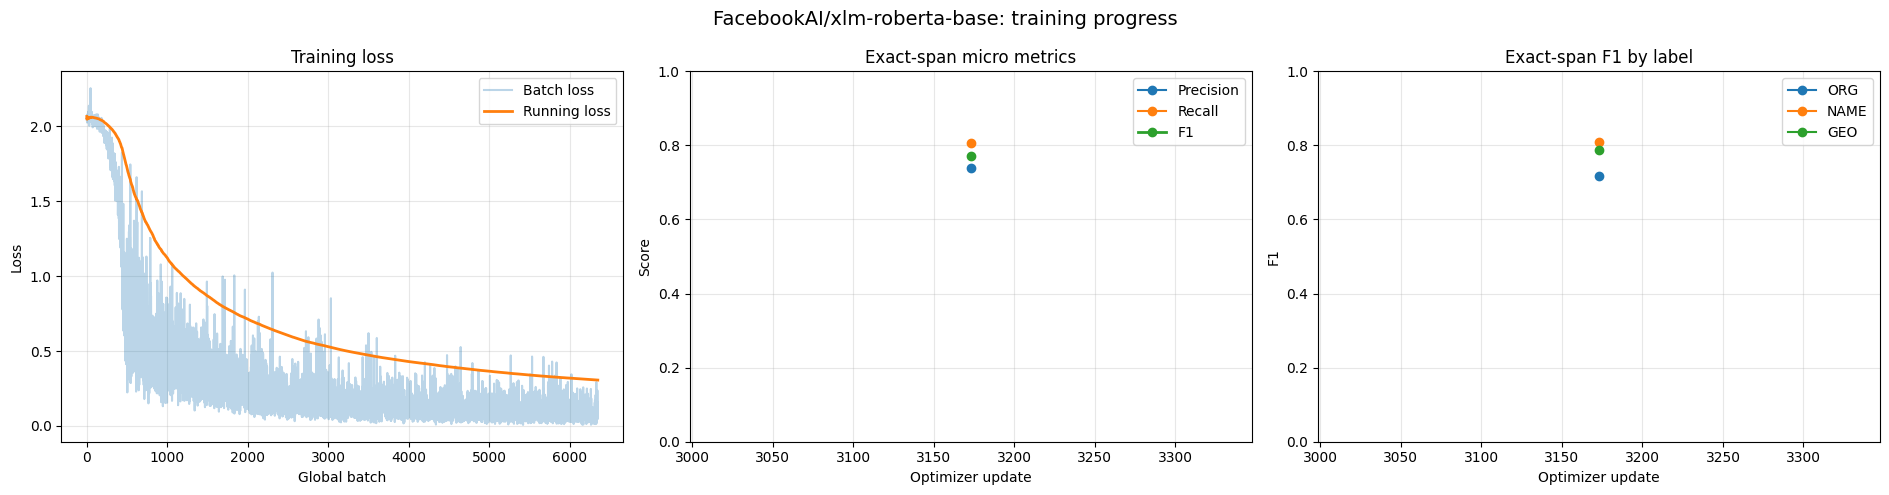

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 1 finished: train_loss=0.306585


Train epoch 2:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8132
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7536     0.8063     0.7791     2144      701      515
NAME         0.8378     0.8154     0.8265     1891      366      428
GEO          0.8233     0.8496     0.8363     2311      496      409
micro        0.8024     0.8244     0.8132     6346     1563     1352
macro        0.8049     0.8238     0.8139
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_01/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8132
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_02/part_3_of_3


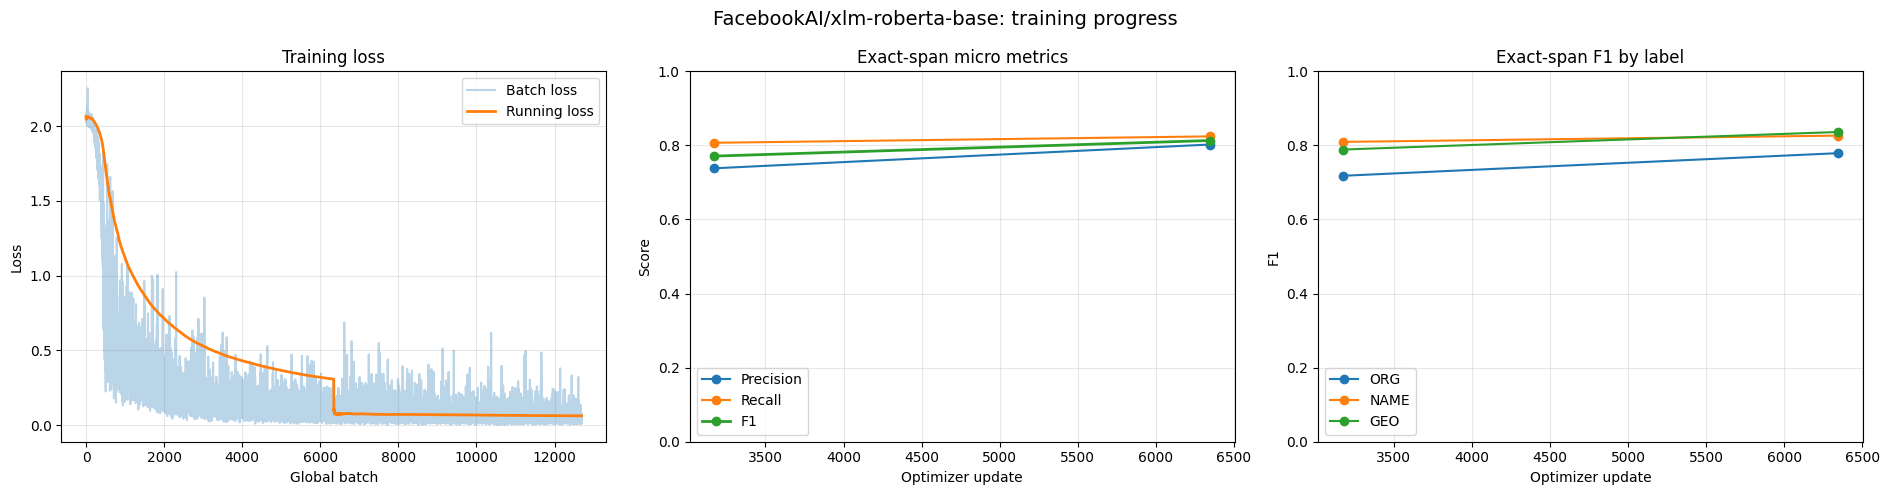

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 2 finished: train_loss=0.061423


Train epoch 3:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8221
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7505     0.8349     0.7905     2220      738      439
NAME         0.7719     0.8797     0.8222     2040      603      279
GEO          0.8354     0.8732     0.8539     2375      468      345
micro        0.7858     0.8619     0.8221     6635     1809     1063
macro        0.7859     0.8626     0.8222
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_02/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8221
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_03/part_3_of_3


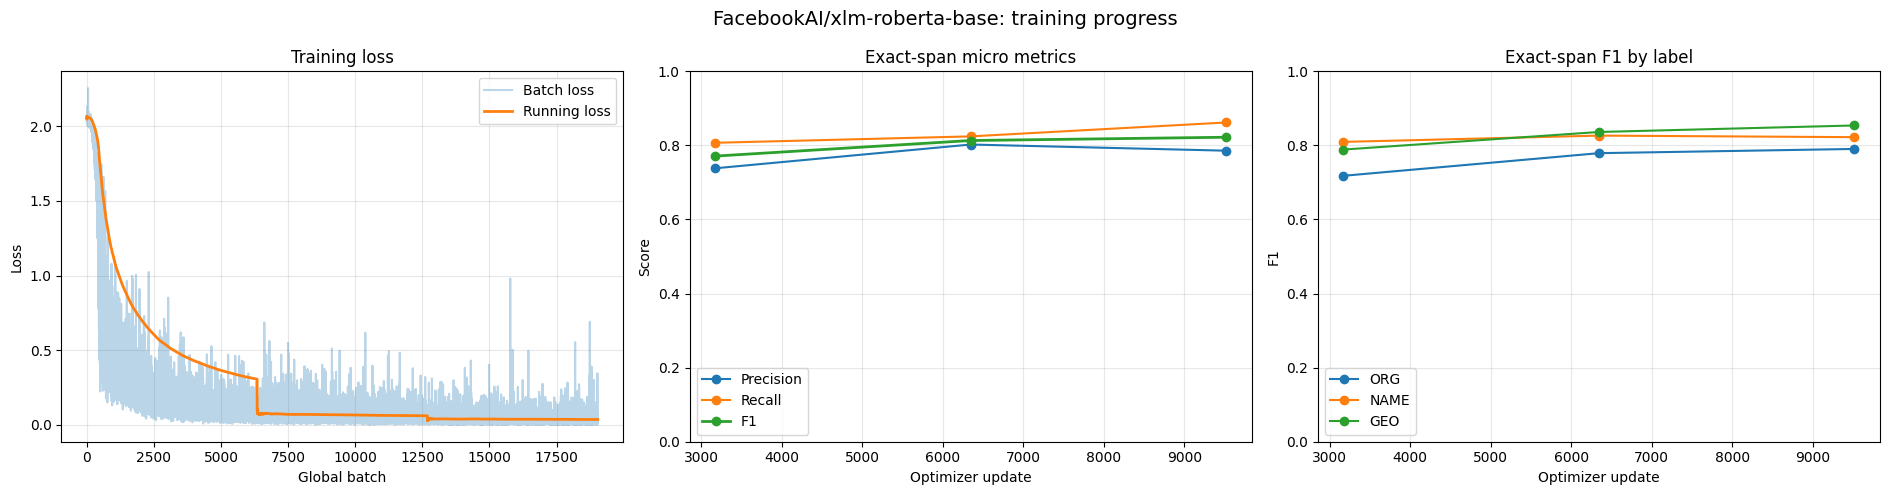

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 3 finished: train_loss=0.036626


Train epoch 4:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8390
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7858     0.8308     0.8077     2209      602      450
NAME         0.8254     0.8642     0.8443     2004      424      315
GEO          0.8492     0.8820     0.8653     2399      426      321
micro        0.8199     0.8589     0.8390     6612     1452     1086
macro        0.8201     0.8590     0.8391
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_03/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8390
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_04/part_3_of_3


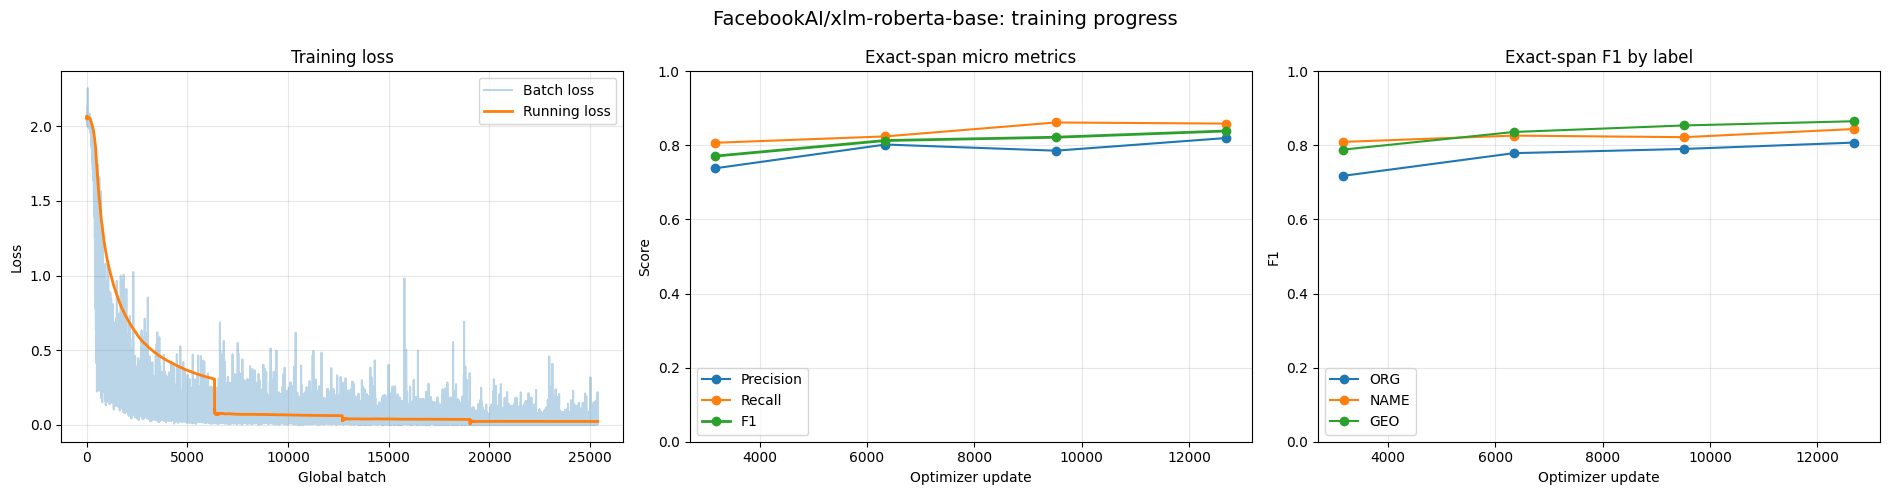

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 4 finished: train_loss=0.023069


Train epoch 5:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8370
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7866     0.8274     0.8065     2200      597      459
NAME         0.8242     0.8473     0.8356     1965      419      354
GEO          0.8580     0.8794     0.8686     2392      396      328
micro        0.8228     0.8518     0.8370     6557     1412     1141
macro        0.8229     0.8514     0.8369
Checkpoint not saved: 0.8370 <= best 0.8390


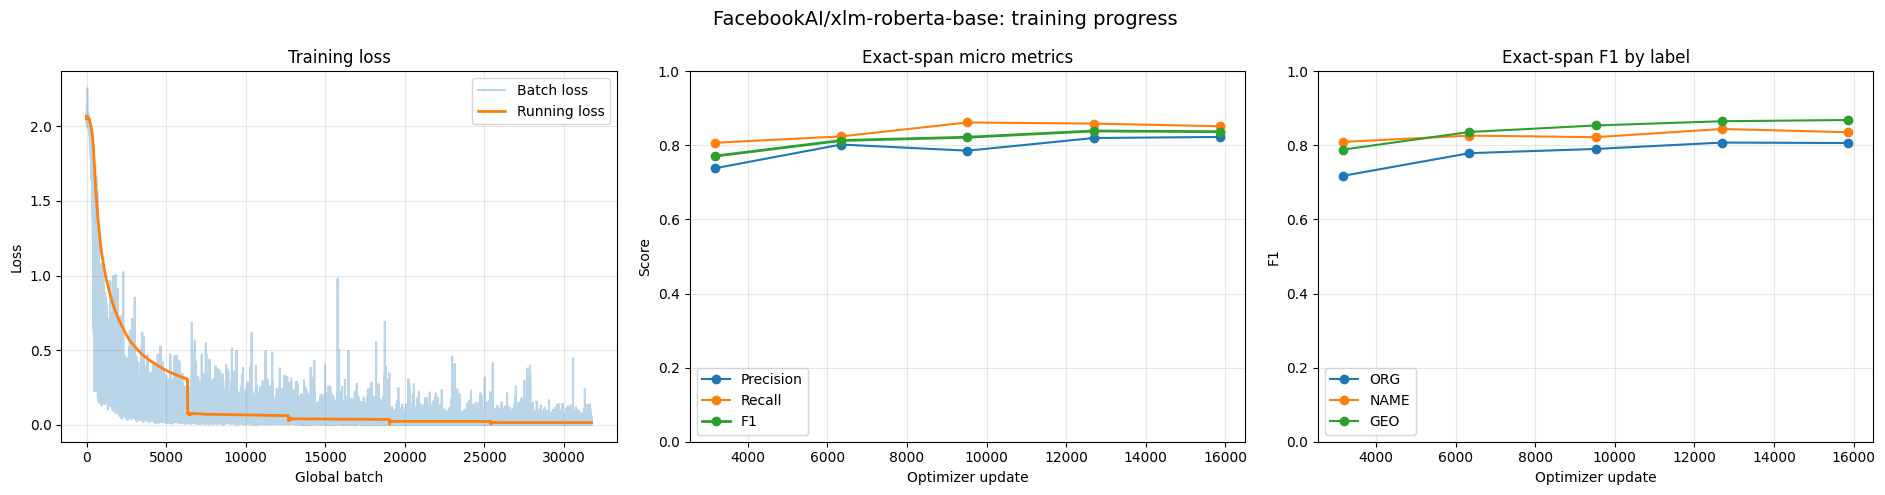

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 5 finished: train_loss=0.015532


Train epoch 6:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8382
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7822     0.8454     0.8126     2248      626      411
NAME         0.8297     0.8448     0.8372     1959      402      360
GEO          0.8434     0.8868     0.8645     2412      448      308
micro        0.8177     0.8598     0.8382     6619     1476     1079
macro        0.8184     0.8590     0.8381
Checkpoint not saved: 0.8382 <= best 0.8390


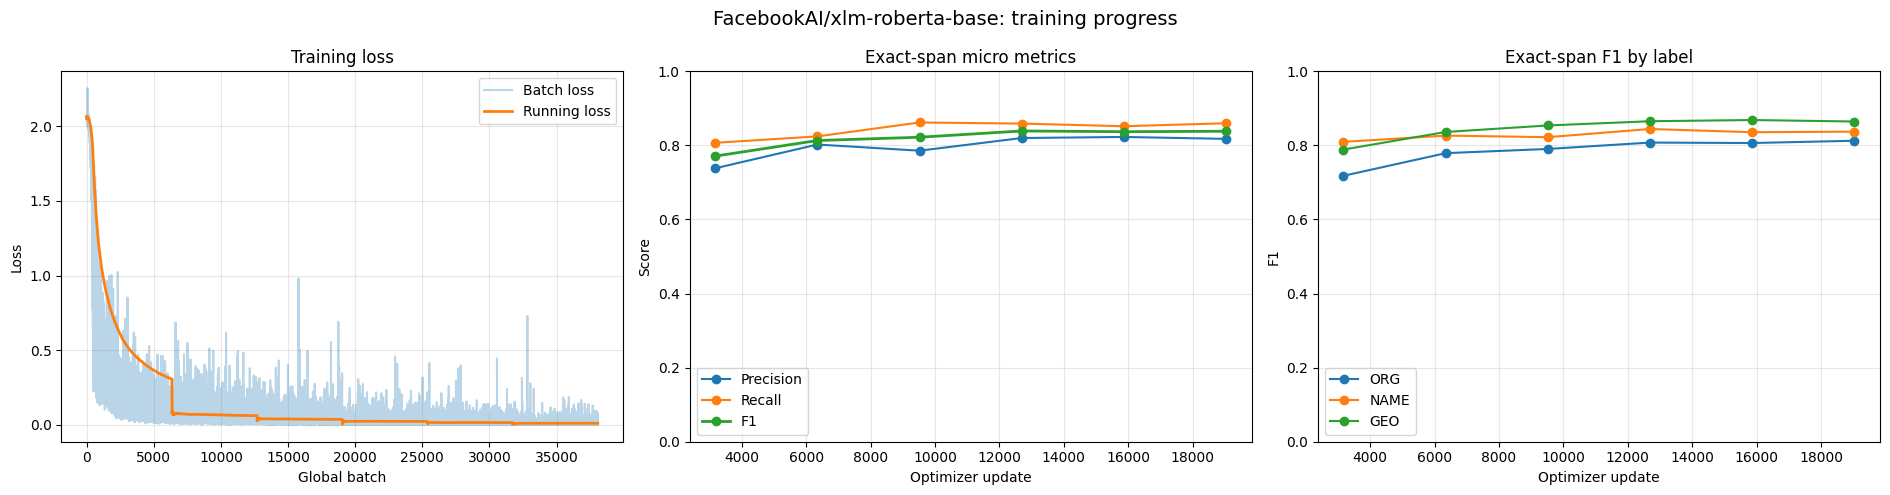

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 6 finished: train_loss=0.011101


Train epoch 7:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8450
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7896     0.8424     0.8151     2240      597      419
NAME         0.8479     0.8676     0.8576     2012      361      307
GEO          0.8577     0.8706     0.8641     2368      393      352
micro        0.8305     0.8600     0.8450     6620     1351     1078
macro        0.8317     0.8602     0.8456
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_04/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8450
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_07/part_3_of_3


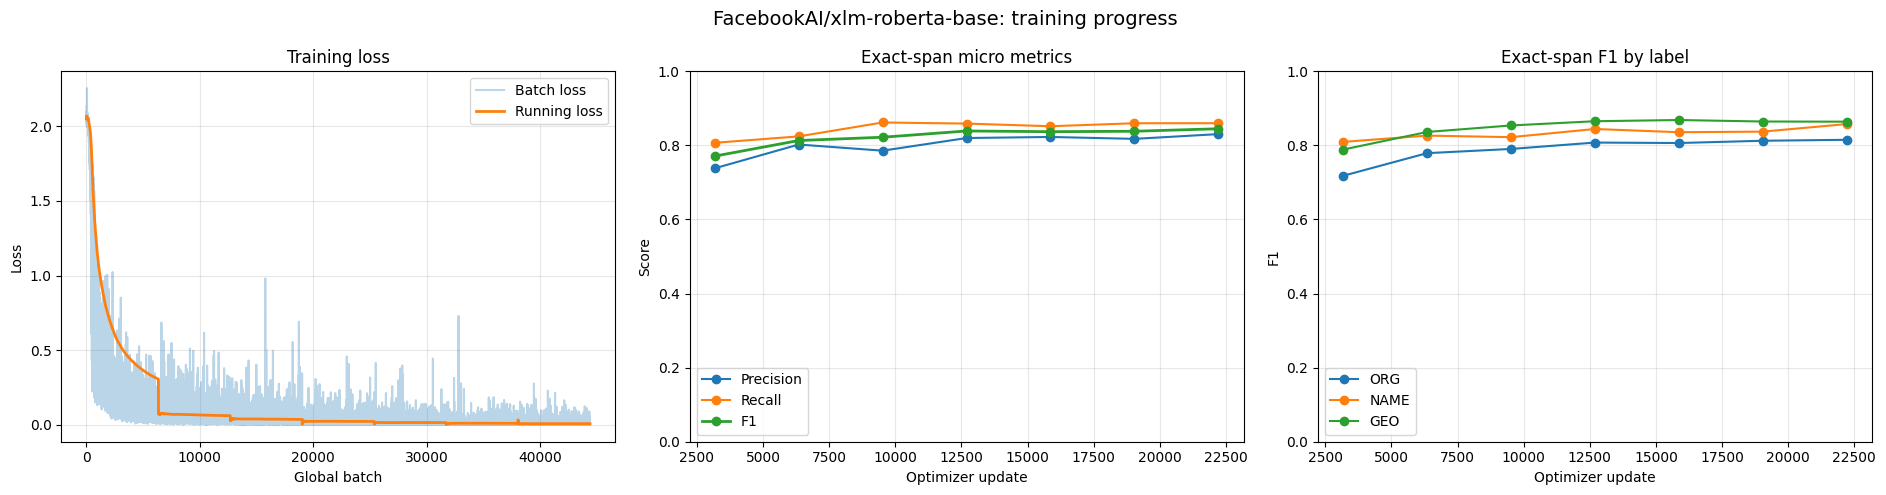

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 7 finished: train_loss=0.008240


Train epoch 8:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8423
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7737     0.8499     0.8100     2260      661      399
NAME         0.8337     0.8693     0.8512     2016      402      303
GEO          0.8563     0.8787     0.8674     2390      401      330
micro        0.8199     0.8659     0.8423     6666     1464     1032
macro        0.8213     0.8660     0.8429
Checkpoint not saved: 0.8423 <= best 0.8450


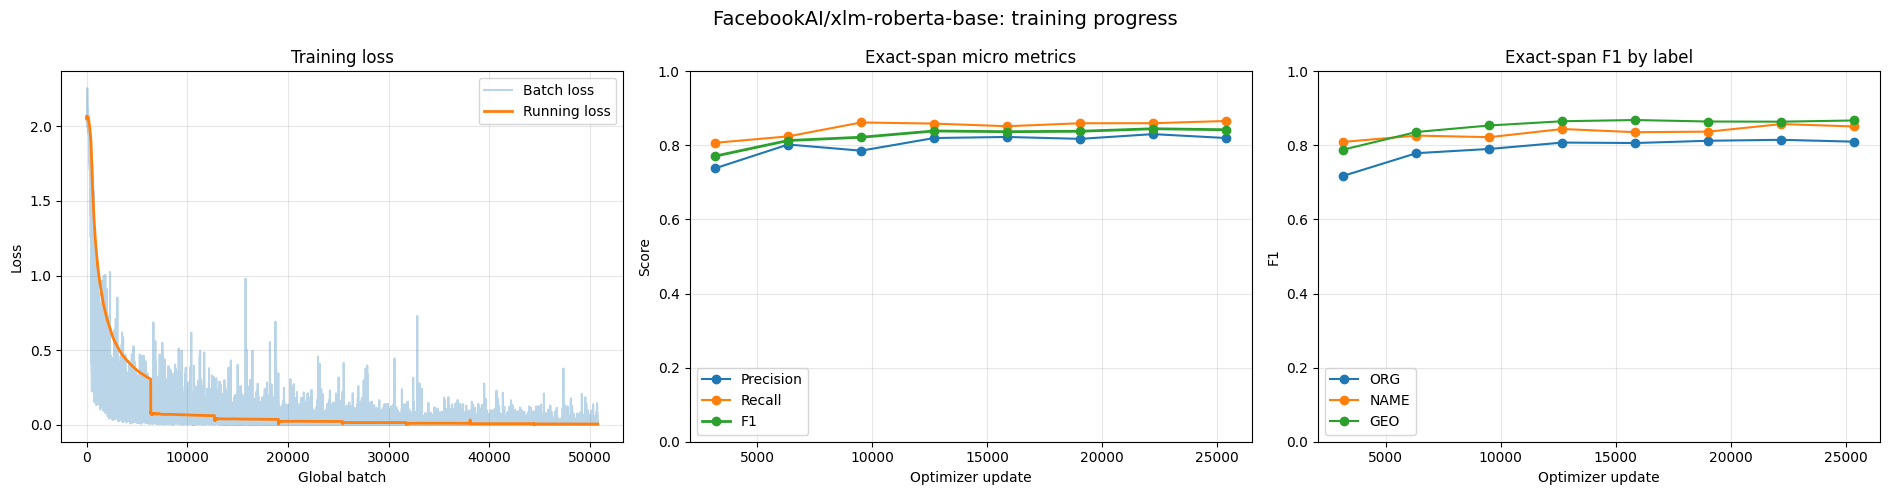

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 8 finished: train_loss=0.005992


Train epoch 9:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8489
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7980     0.8499     0.8232     2260      572      399
NAME         0.8386     0.8624     0.8503     2000      385      319
GEO          0.8685     0.8787     0.8735     2390      362      330
micro        0.8345     0.8639     0.8489     6650     1319     1048
macro        0.8350     0.8637     0.8490
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_07/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8489
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_09/part_3_of_3


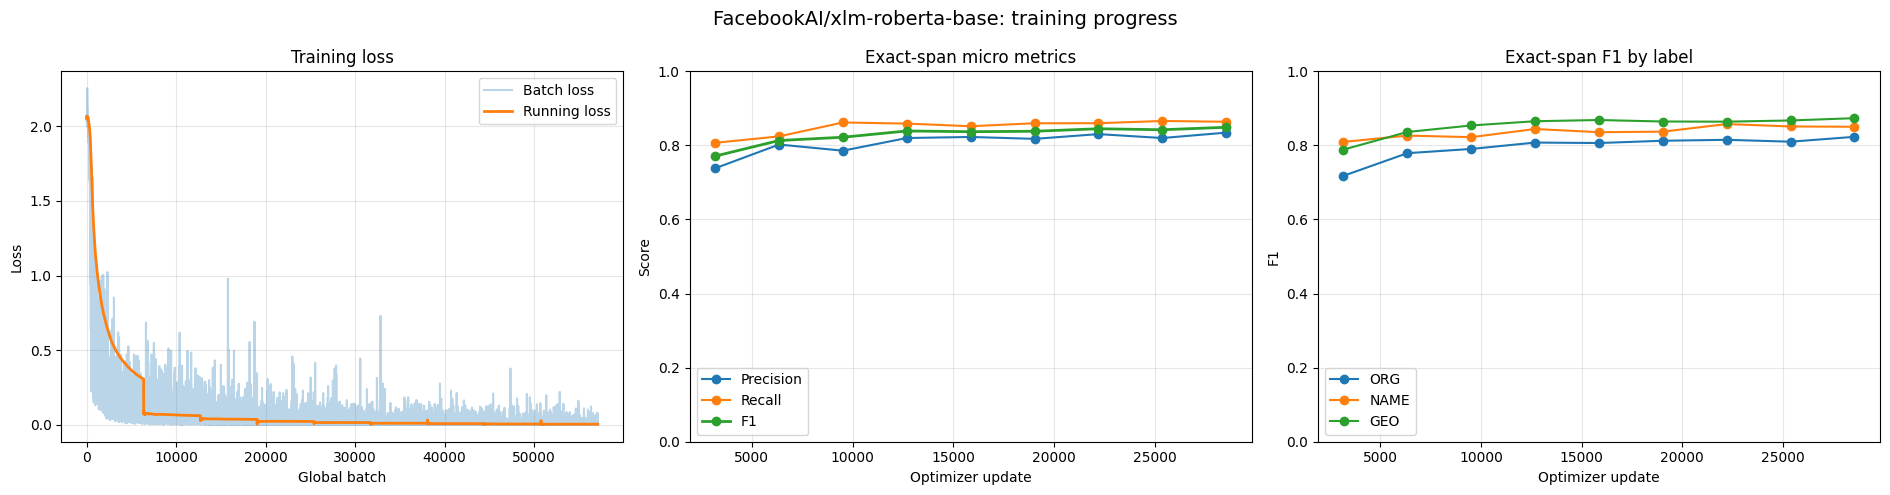

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 9 finished: train_loss=0.004864


Train epoch 10:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8523
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7944     0.8514     0.8219     2264      586      395
NAME         0.8502     0.8737     0.8618     2026      357      293
GEO          0.8704     0.8790     0.8747     2391      356      329
micro        0.8372     0.8679     0.8523     6681     1299     1017
macro        0.8383     0.8680     0.8528
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_09/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8523
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_10/part_3_of_3


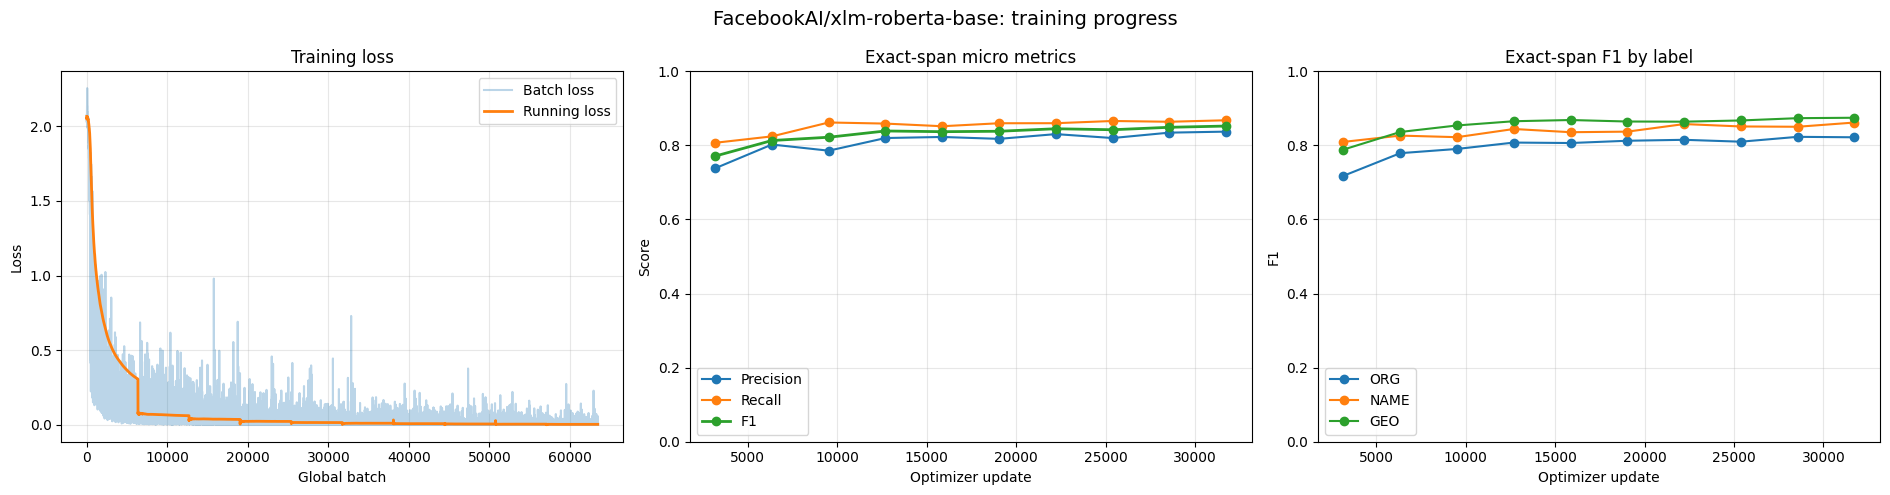

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 10 finished: train_loss=0.003771


Train epoch 11:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8518
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.8130     0.8436     0.8280     2243      516      416
NAME         0.8508     0.8706     0.8606     2019      354      300
GEO          0.8706     0.8654     0.8680     2354      350      366
micro        0.8443     0.8594     0.8518     6616     1220     1082
macro        0.8448     0.8599     0.8522
Checkpoint not saved: 0.8518 <= best 0.8523


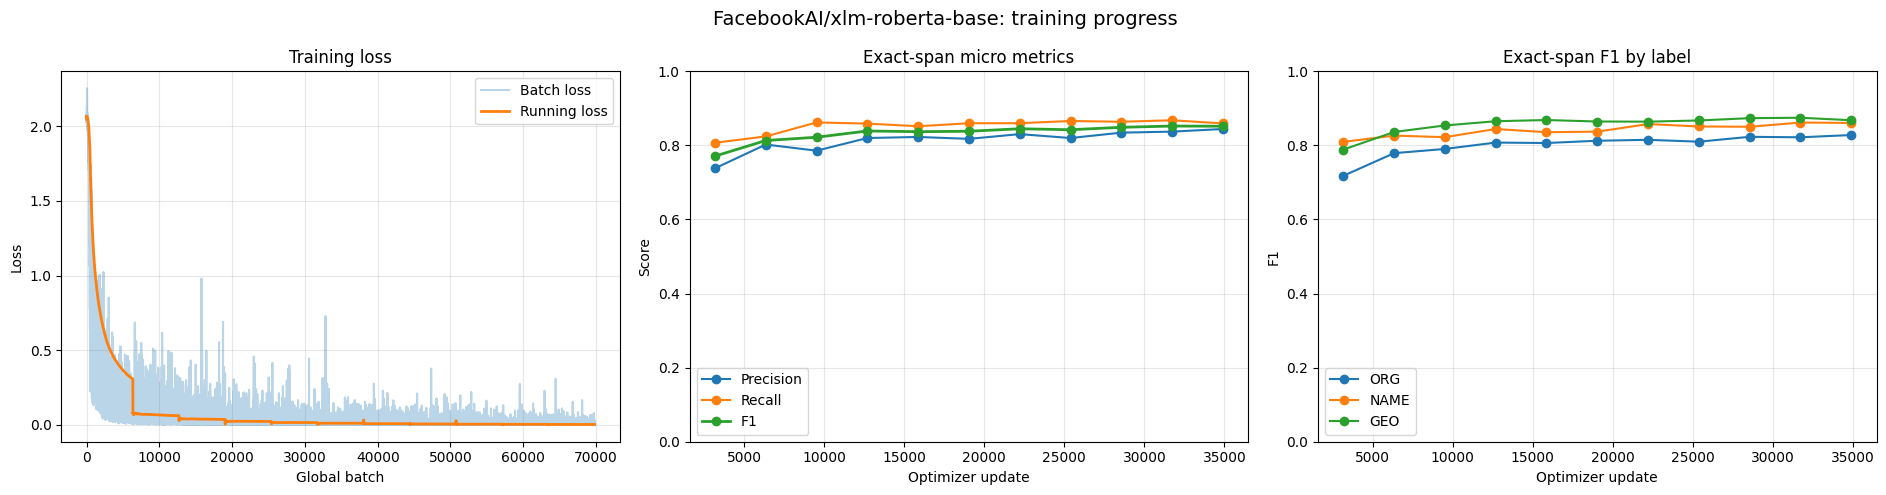

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 11 finished: train_loss=0.002986


Train epoch 12:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8493
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7945     0.8477     0.8202     2254      583      405
NAME         0.8372     0.8762     0.8563     2032      395      287
GEO          0.8668     0.8779     0.8723     2388      367      332
micro        0.8323     0.8670     0.8493     6674     1345     1024
macro        0.8328     0.8673     0.8496
Checkpoint not saved: 0.8493 <= best 0.8523


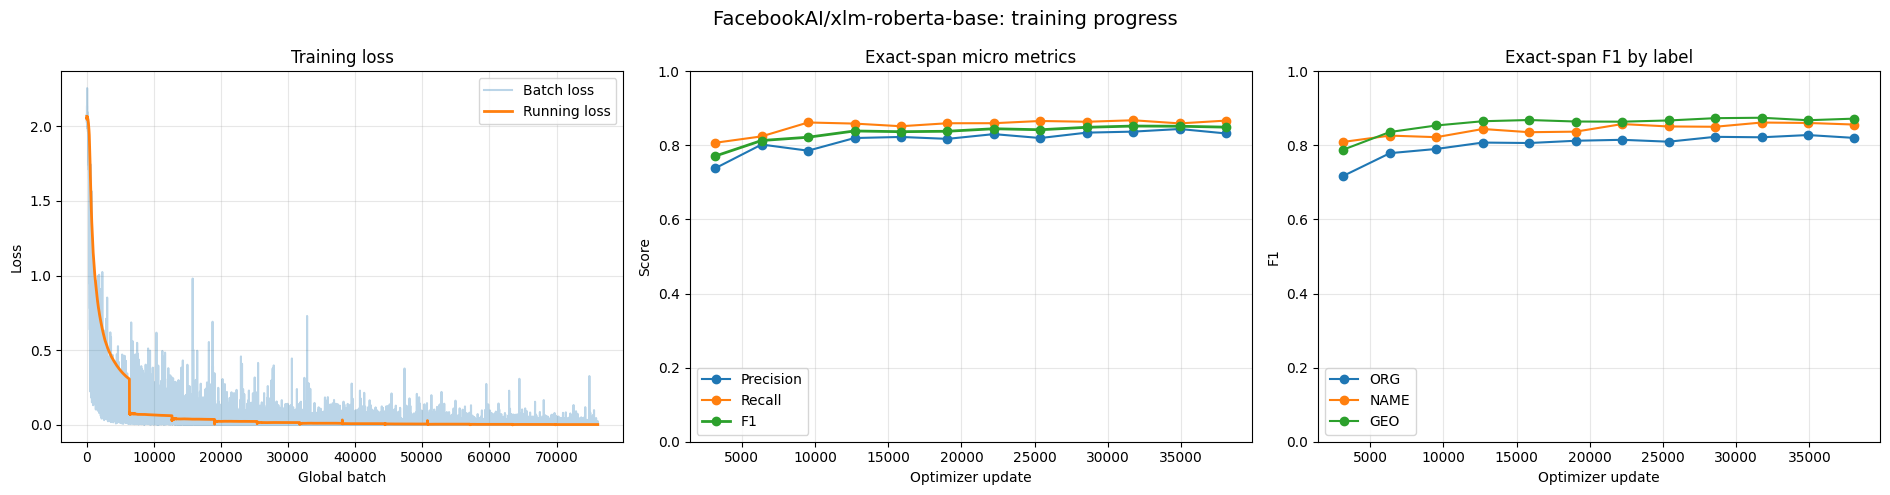

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 12 finished: train_loss=0.002324


Train epoch 13:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8516
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7855     0.8620     0.8219     2292      626      367
NAME         0.8209     0.9030     0.8600     2094      457      225
GEO          0.8607     0.8879     0.8740     2415      391      305
micro        0.8219     0.8835     0.8516     6801     1474      897
macro        0.8223     0.8843     0.8520
Checkpoint not saved: 0.8516 <= best 0.8523


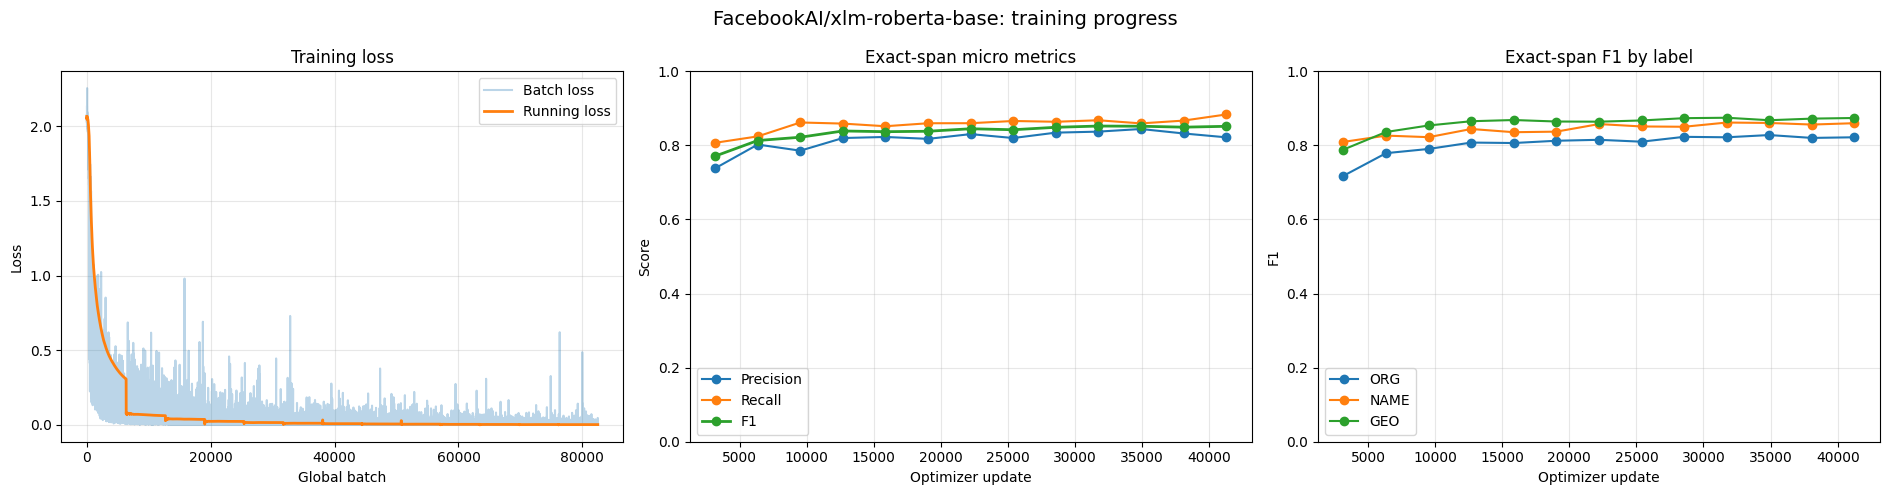

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 13 finished: train_loss=0.001943


Train epoch 14:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8476
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.7807     0.8650     0.8207     2300      646      359
NAME         0.8425     0.8607     0.8515     1996      373      323
GEO          0.8644     0.8790     0.8717     2391      375      329
micro        0.8275     0.8687     0.8476     6687     1394     1011
macro        0.8292     0.8682     0.8480
Checkpoint not saved: 0.8476 <= best 0.8523


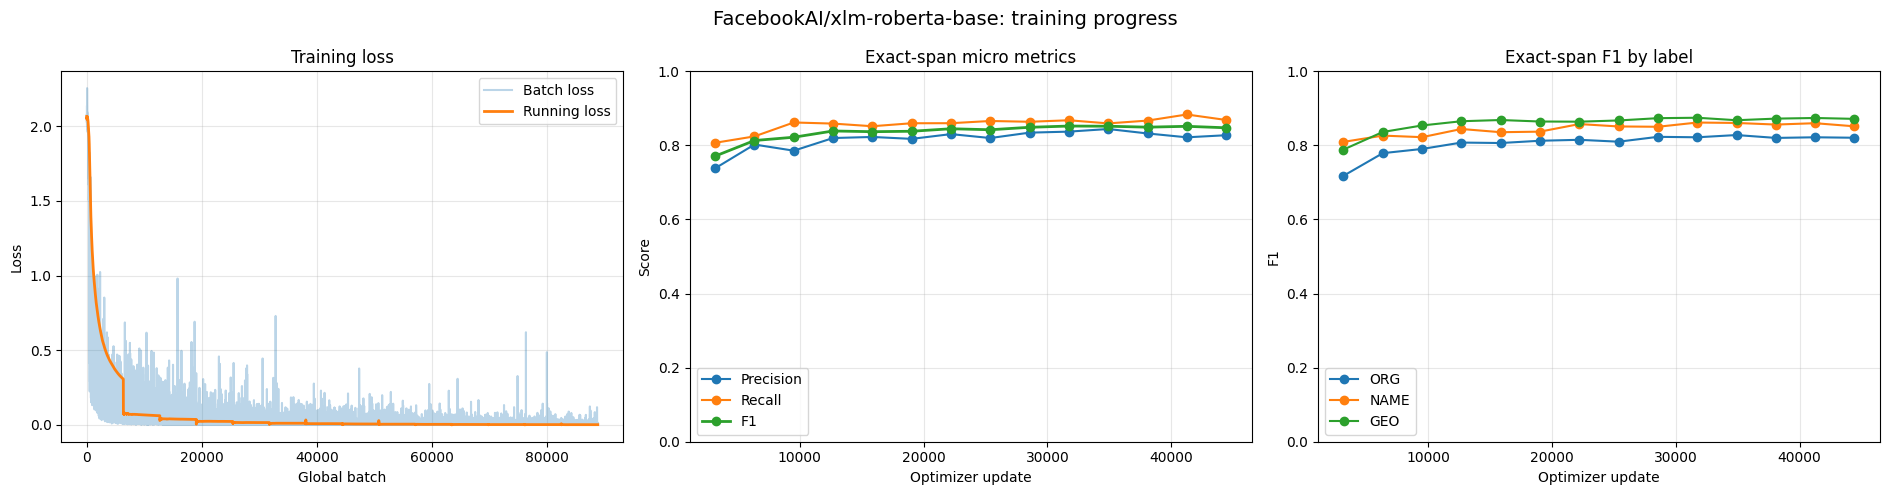

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 14 finished: train_loss=0.001528


Train epoch 15:   0%|          | 0/6346 [00:00<?, ?batch/s]

Predict:   0%|          | 0/106 [00:00<?, ?batch/s]


Evaluation 3/3: micro-F1=0.8553
scope     precision     recall         f1       tp       fp       fn
------------------------------------------------------------------------
ORG          0.8036     0.8556     0.8288     2275      556      384
NAME         0.8502     0.8689     0.8595     2015      355      304
GEO          0.8772     0.8798     0.8785     2393      335      327
micro        0.8429     0.8681     0.8553     6683     1246     1015
macro        0.8437     0.8681     0.8556
Previous best checkpoint removed: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_10/part_3_of_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved: micro-F1=0.8553
Checkpoint: /kaggle/working/artifacts/baseline_notebook/checkpoints/epoch_15/part_3_of_3


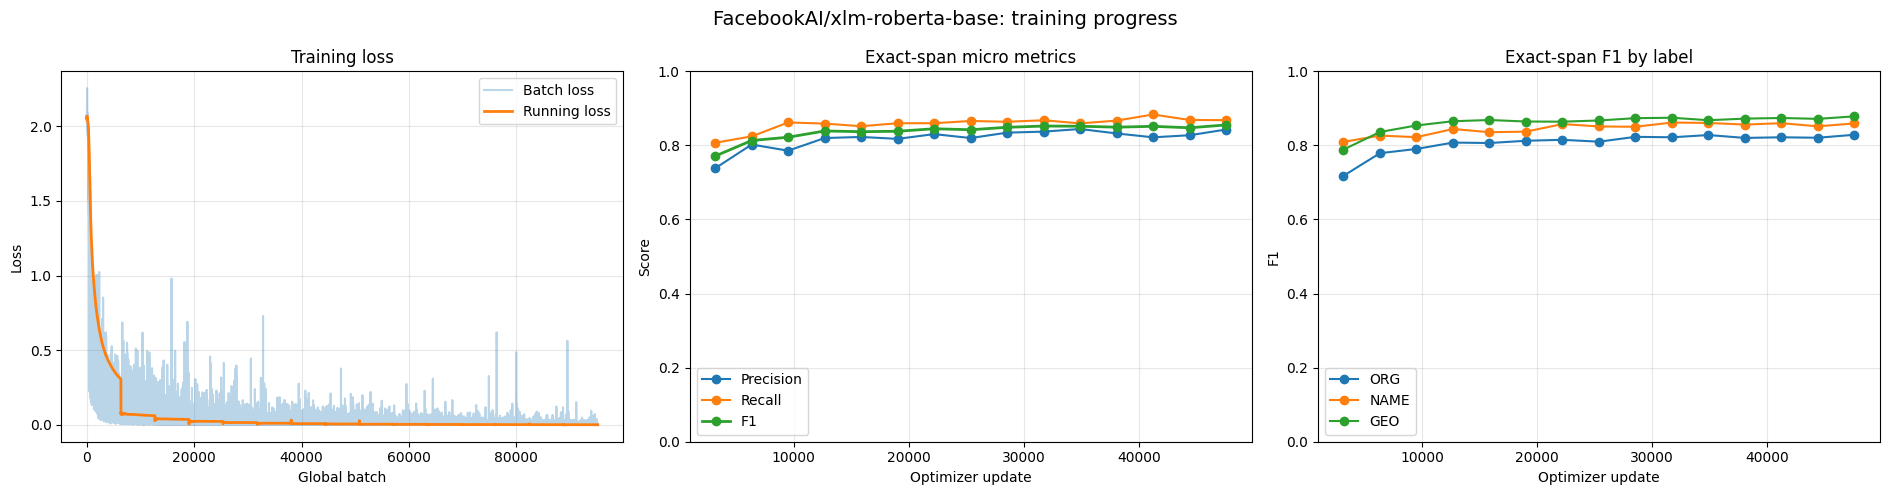

Plot saved: /kaggle/working/artifacts/baseline_notebook/plots/training_curves.png

Epoch 15 finished: train_loss=0.001196


Train epoch 16:   0%|          | 0/6346 [00:00<?, ?batch/s]

In [ ]:
import shutil

train_history: list[dict[str, Any]] = []
eval_history: list[dict[str, Any]] = []

best_f1 = -1.0
best_checkpoint = None
best_predictions = None
best_metrics = None

global_batch = 0
global_update = 0
started = time.time()

for epoch in range(1, CFG.epochs + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    weighted_loss = 0.0
    labeled_tokens = 0
    epoch_updates = 0

    # Три момента evaluation: 1/3, 2/3 и конец эпохи.
    save_points = {
        math.ceil(updates_per_epoch * part / 3): part
        for part in [3]
    }

    progress = tqdm(
        train_loader,
        desc=f"Train epoch {epoch}",
        unit="batch",
    )

    for batch_index, batch in enumerate(
        progress,
        start=1,
    ):
        global_batch += 1
        batch = move_batch(batch)

        group_start = (
            (batch_index - 1)
            // CFG.gradient_accumulation_steps
            * CFG.gradient_accumulation_steps
        )

        group_size = min(
            CFG.gradient_accumulation_steps,
            len(train_loader) - group_start,
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(**batch)
            loss = output.loss

        scaler.scale(
            loss / group_size
        ).backward()

        batch_labeled_tokens = int(
            (batch["labels"] != -100).sum().item()
        )

        weighted_loss += (
            float(loss.detach().item())
            * batch_labeled_tokens
        )

        labeled_tokens += batch_labeled_tokens

        running_loss = (
            weighted_loss
            / max(labeled_tokens, 1)
        )

        train_history.append({
            "epoch": epoch,
            "batch": batch_index,
            "global_batch": global_batch,
            "loss": float(loss.detach().item()),
            "running_loss": running_loss,
        })

        should_step = (
            batch_index
            % CFG.gradient_accumulation_steps
            == 0
            or batch_index == len(train_loader)
        )

        if should_step:
            scaler.unscale_(optimizer)

            clip_grad_norm_(
                model.parameters(),
                CFG.max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

            epoch_updates += 1
            global_update += 1

        progress.set_postfix(
            loss=f"{loss.detach().item():.4f}",
            avg=f"{running_loss:.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

        # Evaluation только после optimizer.step().
        if (
            should_step
            and epoch_updates in save_points
        ):
            part = save_points[epoch_updates]

            # predict_records переводит модель в eval-режим.
            predictions = predict_records(
                model,
                dev_records,
                dev_windows,
            )

            metrics = exact_span_metrics(
                dev_records,
                predictions,
            )

            current_f1 = metrics["micro"]["f1"]

            eval_row = {
                "epoch": epoch,
                "part": part,
                "epoch_update": epoch_updates,
                "global_update": global_update,
                "train_loss": running_loss,
                "micro_precision": (
                    metrics["micro"]["precision"]
                ),
                "micro_recall": (
                    metrics["micro"]["recall"]
                ),
                "micro_f1": current_f1,
                "ORG_f1": (
                    metrics["by_label"]["ORG"]["f1"]
                ),
                "NAME_f1": (
                    metrics["by_label"]["NAME"]["f1"]
                ),
                "GEO_f1": (
                    metrics["by_label"]["GEO"]["f1"]
                ),
            }

            eval_history.append(eval_row)

            print(
                f"\nEvaluation {part}/3: "
                f"micro-F1={current_f1:.4f}"
            )

            print_metrics(metrics)

            # Сохраняем ТОЛЬКО если это новый лучший результат.
            if current_f1 > best_f1:

                # Удаляем предыдущий лучший чекпойнт.
                if (
                    best_checkpoint is not None
                    and Path(best_checkpoint).exists()
                ):
                    shutil.rmtree(
                        best_checkpoint,
                        ignore_errors=True,
                    )

                    print(
                        f"Previous best checkpoint removed: "
                        f"{best_checkpoint}"
                    )

                # Теперь сохраняем новый лучший.
                checkpoint_dir = save_checkpoint(
                    epoch=epoch,
                    part=part,
                    epoch_update=epoch_updates,
                    global_update=global_update,
                    running_train_loss=running_loss,
                    metrics=metrics,
                    predictions=predictions,
                    train_history=train_history,
                    eval_history=eval_history,
                )

                best_f1 = current_f1
                best_checkpoint = checkpoint_dir
                best_predictions = predictions
                best_metrics = metrics

                (
                    ARTIFACT_DIR
                    / "best_checkpoint.json"
                ).write_text(
                    json.dumps(
                        {
                            "epoch": epoch,
                            "part": part,
                            "micro_f1": best_f1,
                            "checkpoint": str(
                                checkpoint_dir
                            ),
                        },
                        ensure_ascii=False,
                        indent=2,
                    )
                    + "\n",
                    encoding="utf-8",
                )

                print(
                    f"New best checkpoint saved: "
                    f"micro-F1={best_f1:.4f}"
                )

                print(
                    f"Checkpoint: {best_checkpoint}"
                )

            else:
                print(
                    f"Checkpoint not saved: "
                    f"{current_f1:.4f} <= "
                    f"best {best_f1:.4f}"
                )

            plot_path = plot_training_history(
                train_history,
                eval_history,
            )

            print(f"Plot saved: {plot_path}")

            # После evaluation возвращаем режим обучения.
            model.train()

    epoch_loss = (
        weighted_loss
        / max(labeled_tokens, 1)
    )

    print(
        f"\nEpoch {epoch} finished: "
        f"train_loss={epoch_loss:.6f}"
    )

    (
        ARTIFACT_DIR / "train_history.json"
    ).write_text(
        json.dumps(
            train_history,
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    (
        ARTIFACT_DIR / "eval_history.json"
    ).write_text(
        json.dumps(
            eval_history,
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )


elapsed_minutes = (
    time.time() - started
) / 60

print(
    f"\nTraining finished in "
    f"{elapsed_minutes:.1f} minutes"
)

print(f"Best micro-F1: {best_f1:.4f}")
print(f"Best checkpoint: {best_checkpoint}")